# Week 2 Assessment Mini-Project

Complete all TODOs below. Keep outputs visible and ensure the notebook runs top to bottom without errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
# TODO: Load the dataset with date parsing and set the index
# File: m1-09-assessment.csv

# df = pd.read_csv("m1-09-assessment.csv", parse_dates=["date"])
# df = df.set_index("date")
df=pd.read_csv("m1-09-assessment.csv",parse_dates=["date"])
df=df.set_index("date")
df_=df.copy()

# TODO: Show head/tail and check info
print(df_.head(),'\n')
print(df_.tail(),'\n')
print(df_.info())

              city  avg_temp_c  humidity_pct   pm25
date                                               
2023-01-01  London       -0.79         62.93  39.39
2023-01-02  London        1.31         61.49  32.41
2023-01-03  London        1.46         76.51  30.61
2023-01-04  London       -0.57         58.05  30.71
2023-01-05  London       -1.13         36.30  20.70 

              city  avg_temp_c  humidity_pct   pm25
date                                               
2023-06-25  Madrid         NaN         72.04   5.00
2023-06-26  Madrid       28.44         74.19   5.00
2023-06-27  Madrid       26.41         64.41   5.24
2023-06-28  Madrid       27.53         86.47  14.86
2023-06-29  Madrid       24.22         74.33    NaN 

<class 'pandas.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    str    
 1   avg_temp_c    863 non-

## Part A: Core Data Handling (TODOs)

- Inspect structure with `info()`, `describe()`, and missing value counts.
- Clean `pm25` by coercing invalid strings to NaN.
- Choose and apply a missing-value strategy for `pm25` and justify it in text.

In [3]:
# TODO: data inspection
# df.info()
# df.describe()
# df.isna().sum()

print(df_.info(),'\n')
print("Description: ",df_.describe(),'\n')
print("Missing values count: ",df_.isna().sum(),'\n')

# TODO: clean pm25
# df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")
df_["pm25"]=pd.to_numeric(df_["pm25"],errors="coerce")

# TODO: handle missing values in pm25 and justify in markdown
df_["pm25"] = df_["pm25"].interpolate(method="time") # i used the copy of data to keep original data without any change

print("nan values in pm25 column after cleaning: ",df_["pm25"].isna().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    str    
 1   avg_temp_c    863 non-null    float64
 2   humidity_pct  900 non-null    float64
 3   pm25          850 non-null    float64
dtypes: float64(3), str(1)
memory usage: 35.2 KB
None 

Description:         avg_temp_c  humidity_pct        pm25
count  863.000000    900.000000  850.000000
mean     9.259849     64.931011   23.961247
std      9.134278     14.432234   11.856849
min    -15.030000     35.000000    5.000000
25%      1.410000     54.672500   14.090000
50%      9.790000     64.870000   23.710000
75%     16.775000     75.190000   33.427500
max     30.390000     95.000000   60.600000 

Missing values count:  city             0
avg_temp_c      37
humidity_pct     0
pm25            50
dtype: int64 

nan values in pm25 column after cleaning:  0


# handling missing values
I used time-based interpolation to fill the missing values in the pm25 column.
Since PM2.5 data is time-series data, the values change gradually over time. 
Using `method="time considers the actual time intervals between observations when filling missing values.
This approach preserves the natural trend of the data and provides more realistic estimates compared to simply removing missing values or filling them with a constant number.

# Part B: Required Analysis (TODOs)
- Data quality analysis: city with highest % invalid/missing pm25.
- Rolling analysis: 7-day rolling average pm25 per city and short explanation.
- Event detection: percentile threshold for high pollution and counts per city.
- Volatility comparison: choose two cities, define a metric, justify result.
- Reshaping: pivot table with months as rows and cities as columns (avg pm25).

In [4]:
# TODO: analysis tasks
# - data quality by city
invalid_pct = (df["pm25"].isna().groupby(df["city"]).mean() * 100)
print("city with highest % missing pm25: ",invalid_pct.idxmax(), invalid_pct.max(),'\n')
# i used original dataset, because in copied dataset i have filled all the nan values


# - rolling averages per city
df_ = df_.sort_values(["city", "date"])
df_["pm25_7day_avg"] = (df_.groupby("city")["pm25"].transform(lambda s: s.rolling(window=7).mean()))
print("# - rolling averages per city",df_["pm25_7day_avg"][:15],'\n')


# - percentile-based event counts
threshold = df_["pm25"].quantile(0.90)
high_mask = df_["pm25"] > threshold
high_pollution_events=high_mask.groupby(df_["city"]).sum()
print("high_pollution_events",high_pollution_events,'\n')


# - volatility comparison
volatility = df_.groupby("city")["pm25"].std()

city1_name = volatility.index[0]
city2_name = volatility.index[1]

city1_value = volatility.iloc[0]
city2_value = volatility.iloc[1]

if city1_value>city2_value:
    print(f"{city1_name} has more volatility",'\n')
else: 
    print(f"{city2_name} has more volatility",'\n')


# - pivot table by month and city
pivoted = df_.pivot_table(
    index=pd.Grouper(freq="ME"),
    columns="city",
    values="pm25",
    aggfunc="mean")

print(pivoted)

city with highest % missing pm25:  Berlin 7.777777777777778 

# - rolling averages per city date
2023-01-01          NaN
2023-01-02          NaN
2023-01-03          NaN
2023-01-04          NaN
2023-01-05          NaN
2023-01-06          NaN
2023-01-07    34.588571
2023-01-08    33.678571
2023-01-09    32.324286
2023-01-10    31.558571
2023-01-11    32.165714
2023-01-12    31.074286
2023-01-13    29.924286
2023-01-14    29.161429
2023-01-15    29.780000
Name: pm25_7day_avg, dtype: float64 

high_pollution_events city
Berlin    14
London    17
Madrid    20
Paris     17
Warsaw    22
Name: pm25, dtype: int64 

London has more volatility 

city           Berlin     London     Madrid      Paris     Warsaw
date                                                             
2023-01-31  33.193226  33.275806  33.006452  35.021935  37.239032
2023-02-28  33.117500  33.274286  34.651786  34.326786  34.818571
2023-03-31  29.531613  29.737742  30.315484  26.736774  27.736129
2023-04-30  21.855667  24.8

# rolling averages per city
A 7-day rolling average helps reduce daily fluctuations in PM2.5 values. It smooths the data and makes the overall trend easier to see. This helps to understand whether pollution is generally increasing or decreasing over time.

# volatility comparison
I used standard deviation to measure volatility.Standard deviation shows how much PM2.5 values change over time.  
A higher value means pollution levels fluctuate more.

based on the result,London has a higher standard deviation than Berlin. Therefore, London is more volatile than Berlin

# monthly pivot table
I calculated the average PM2.5 per month for each city.This helps compare cities and see pollution patterns over time.


## Part C: Aggregations (TODOs)

- Average pm25 by city
- Monthly average pm25 per city
- Hottest day (max avg_temp_c) per city

In [5]:
# TODO: aggregation tasks
# avg_pm25_by_city = ...
avg_pm25_by_city =df_.groupby("city")["pm25"].mean()
# monthly_avg_pm25 = ...
monthly_avg_pm25=(df_.groupby(["city", pd.Grouper(freq="ME")])["pm25"].mean())
# hottest_day_per_city = ...
hottest_day_per_city = df_.groupby("city")["avg_temp_c"].idxmax()


print("average pm25 by city: ",avg_pm25_by_city,'\n')
print("monthly average pm25 per city: ",monthly_avg_pm25,'\n')
print("the hottest day per city: ",hottest_day_per_city,'\n')

average pm25 by city:  city
Berlin    23.805333
London    24.047389
Madrid    24.254556
Paris     23.733278
Warsaw    24.017556
Name: pm25, dtype: float64 

monthly average pm25 per city:  city    date      
Berlin  2023-01-31    33.193226
        2023-02-28    33.117500
        2023-03-31    29.531613
        2023-04-30    21.855667
        2023-05-31    15.200645
        2023-06-30     9.872759
London  2023-01-31    33.275806
        2023-02-28    33.274286
        2023-03-31    29.737742
        2023-04-30    24.864333
        2023-05-31    13.987742
        2023-06-30     9.099310
Madrid  2023-01-31    33.006452
        2023-02-28    34.651786
        2023-03-31    30.315484
        2023-04-30    22.269000
        2023-05-31    15.118387
        2023-06-30    10.201724
Paris   2023-01-31    35.021935
        2023-02-28    34.326786
        2023-03-31    26.736774
        2023-04-30    23.049333
        2023-05-31    14.055161
        2023-06-30     9.280345
Warsaw  2023-01-31    37

## Part D: Visualization (TODOs)

- Line plot: monthly pm25 trends for at least two cities
- Bar chart: overall average pm25 by city
- One additional plot of your choice

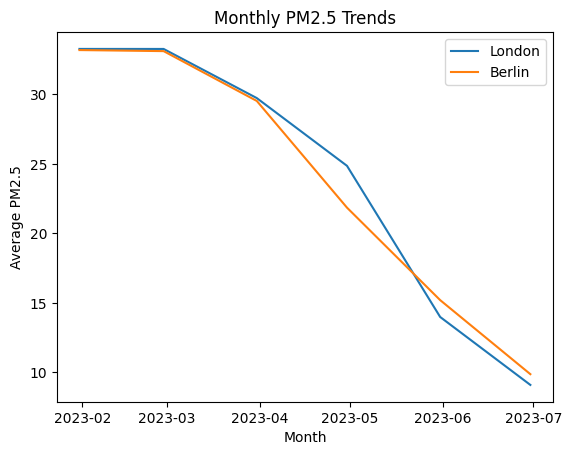

In [6]:
# TODO: plotting section
# plt.figure(...)
# plt.plot(...)
# plt.bar(...)
# plt.show()


#Line plot of monthly pm25 trends for at least two cities.
monthly = (df_.groupby(["city", pd.Grouper(freq="ME")])["pm25"].mean().reset_index())

plt.figure()

for city in ["London", "Berlin"]:
    city_data = monthly[monthly["city"] == city]
    plt.plot(city_data["date"], city_data["pm25"], label=city)

plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly PM2.5 Trends")
plt.legend()
plt.show()

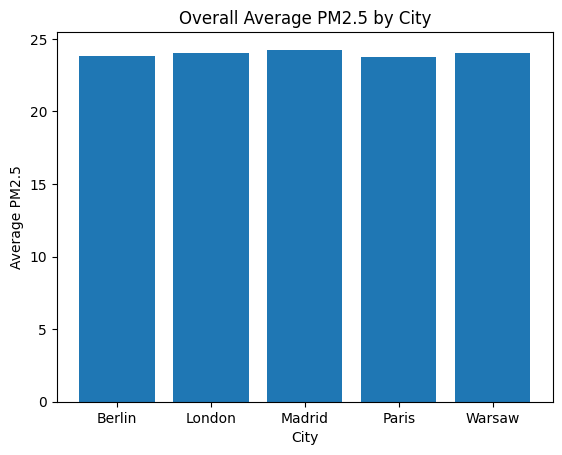

In [7]:
#Bar chart of overall average pm25 by city.

plt.figure()
plt.bar(avg_pm25_by_city.index, avg_pm25_by_city.values)

plt.xlabel("City")
plt.ylabel("Average PM2.5")
plt.title("Overall Average PM2.5 by City")
plt.show()

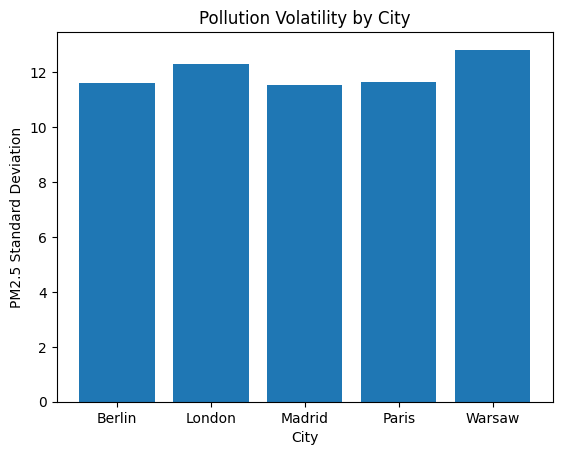

In [8]:
volatility = df_.groupby("city")["pm25"].std()

plt.figure()
plt.bar(volatility.index, volatility.values)

plt.xlabel("City")
plt.ylabel("PM2.5 Standard Deviation")
plt.title("Pollution Volatility by City")
plt.show()

# Pollution Volatility by City

I created a bar chart to show the standard deviation of PM2.5 for each city.

The bars represent the standard deviation.Higher bars mean pollution changes more from day to day and Lower bars mean pollution is more stable.
This plot helps us easily see which cities have more changing pollution levels.

## Part E: Interpretation Questions (TODOs)

Write short answers here:

1. Which city shows the most persistent high pm25 levels, and what evidence supports that?
2. How does missing or invalid data affect your confidence in the results?
3. Does temperature appear related to pm25 in your analysis? Explain briefly.
4. What is one limitation of using daily averages for air-quality policy decisions?
5. If you had one more dataset to improve this analysis, what would it be and why?

# 1
London shows the most persistent high PM2.5 levels.

London has the highest overall average PM2.5. This shows that pollution levels remained consistently high during the whole period. The high average indicates that the pollution was continuously elevated, not just on a few days.

# 2
Missing or invalid data slightly reduces confidence in our results because some PM2.5 values were missing and had to be interpolated. This means certain pollution levels were estimated rather than directly measured. As a result, extreme spikes or sudden changes might be smoothed out, so the analysis may not perfectly reflect real daily conditions.

# 3
Based on the monthly trends, PM2.5 levels are higher during colder months and lower during warmer months, suggesting a negative relationship between temperature and pollution.

# 4
Daily averages can hide short-term pollution spikes. If pollution is very high for a few hours but lower during the rest of the day, the daily average may look normal. This means important risks might not be clearly visible in the results.

# 5
If I had one more dataset, I would choose Traffic Density. This would help me understand if the high pm25 levels in cities like Madrid and Warsaw are caused by cars or other sources like heating and factories. It would also show if rush-hour traffic is the main reason for the daily pollution spikes.